In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving diabetes_readmission_100_records.xlsx to diabetes_readmission_100_records.xlsx


In [5]:
import pandas as pd

df = pd.read_excel('diabetes_readmission_100_records.xlsx')

df.head()

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide_metformin,glipizide_metformin,glimepiride_pioglitazone,metformin_rosiglitazone,metformin_pioglitazone
0,Caucasian,unknown/invalid,[20-30),226,4,6,15,7,SP,Orthopedics,...,no,up,up,up,down,down,no,up,no,no
1,Other,female,[80-90),154,9,28,1,11,UN,Cardiology,...,down,up,up,no,up,down,down,no,down,steady
2,Other,unknown/invalid,[60-70),144,9,25,7,12,SP,Surgery,...,down,no,no,down,up,up,no,steady,no,no
3,Hispanic,unknown/invalid,[0-10),115,1,13,11,13,BC,InternalMedicine,...,no,steady,no,steady,no,no,down,down,steady,down
4,Caucasian,unknown/invalid,[80-90),105,6,2,2,10,HM,Neurology,...,up,up,no,up,up,down,steady,down,steady,up


In [6]:
df.shape

(100, 48)

In [7]:
df.columns

Index(['race', 'gender', 'age', 'weight', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'payer_code', 'medical_specialty', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3',
       'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'change',
       'diabetesMed', 'readmitted', 'metformin', 'repaglinide', 'nateglinide',
       'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide',
       'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
       'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton',
       'insulin', 'glyburide_metformin', 'glipizide_metformin',
       'glimepiride_pioglitazone', 'metformin_rosiglitazone',
       'metformin_pioglitazone'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 48 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   race                      100 non-null    object
 1   gender                    100 non-null    object
 2   age                       100 non-null    object
 3   weight                    100 non-null    int64 
 4   admission_type_id         100 non-null    int64 
 5   discharge_disposition_id  100 non-null    int64 
 6   admission_source_id       100 non-null    int64 
 7   time_in_hospital          100 non-null    int64 
 8   payer_code                100 non-null    object
 9   medical_specialty         100 non-null    object
 10  num_lab_procedures        100 non-null    int64 
 11  num_procedures            100 non-null    int64 
 12  num_medications           100 non-null    int64 
 13  number_outpatient         100 non-null    int64 
 14  number_emergency          1

In [9]:
df.isnull().sum()

,0
race,0
gender,0
age,0
weight,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0
payer_code,0
medical_specialty,0


In [10]:
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_1232/3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [12]:
df.columns

Index(['race', 'gender', 'age', 'weight', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'payer_code', 'medical_specialty', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3',
       'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'change',
       'diabetesMed', 'readmitted', 'metformin', 'repaglinide', 'nateglinide',
       'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide',
       'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
       'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton',
       'insulin', 'glyburide_metformin', 'glipizide_metformin',
       'glimepiride_pioglitazone', 'metformin_rosiglitazone',
       'metformin_pioglitazone'],
      dtype='object')

In [15]:
df['diag_1']=df['diag_1'].astype(str).str.lower().str.strip()

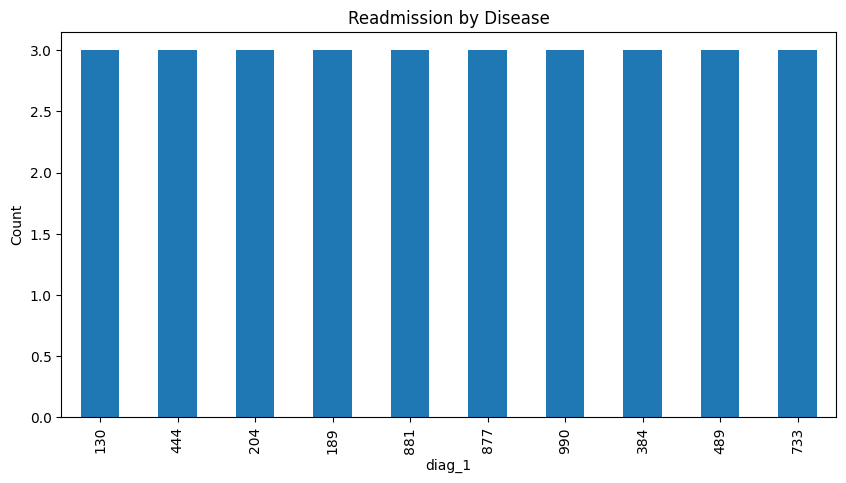

In [17]:
readmission_disease = df.groupby('diag_1')['readmitted'].count().sort_values(ascending=False).head(10)

readmission_disease.plot(kind='bar', figsize=(10,5))

plt.title('Readmission by Disease')

plt.ylabel('Count')

plt.show()

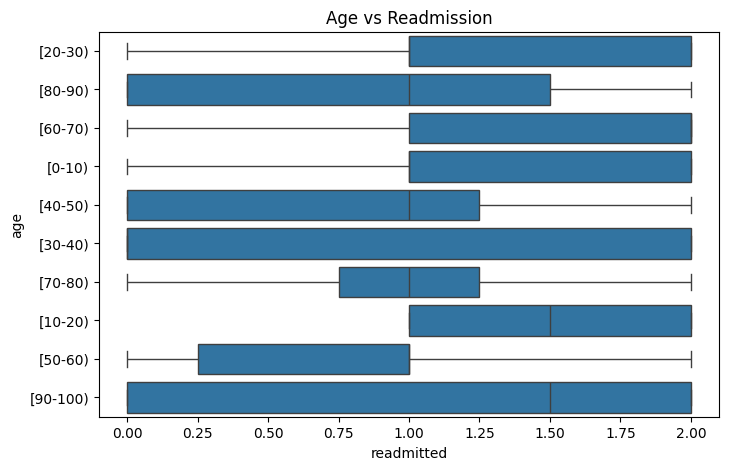

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x='readmitted',y='age',data=df)
plt.title('Age vs Readmission')
plt.show()

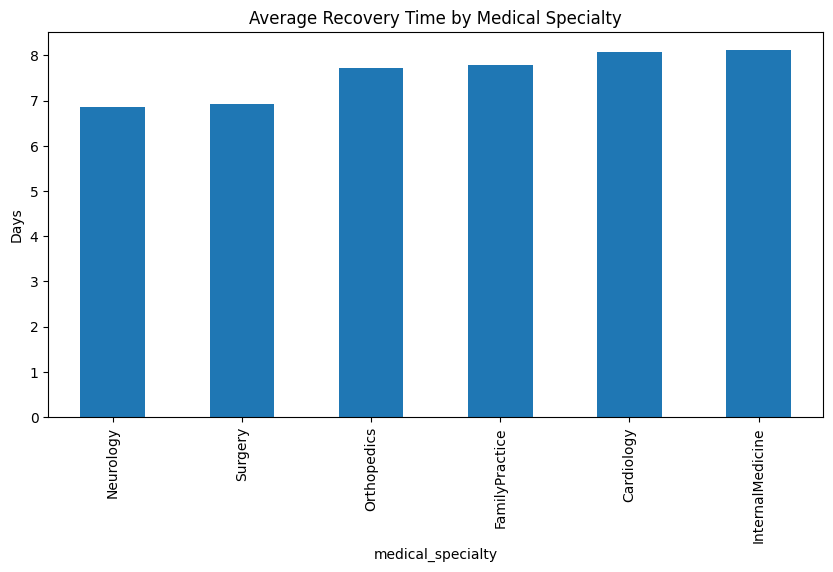

In [19]:
doctor_recovery= df.groupby('medical_specialty')['time_in_hospital'].mean().sort_values().head(10)
doctor_recovery.plot(kind='bar',figsize=(10,5))
plt.title('Average Recovery Time by Medical Specialty')
plt.ylabel('Days')
plt.show()

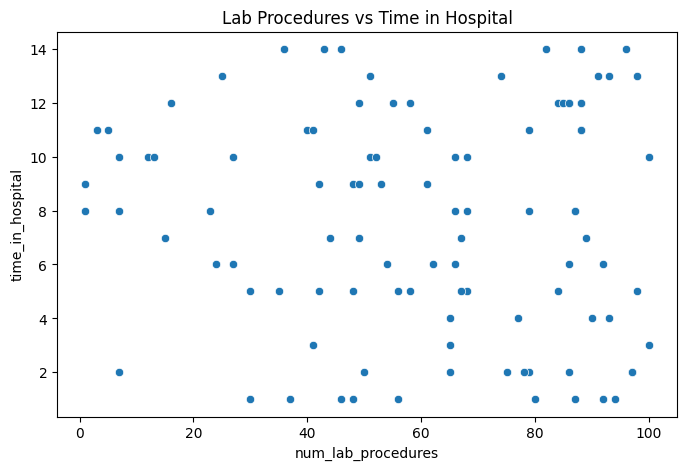

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='num_lab_procedures',y='time_in_hospital',data=df)
plt.title('Lab Procedures vs Time in Hospital')
plt.show()

In [21]:
top_disease=df.groupby('diag_1')['readmitted'].count().sort_values(ascending=False).head(10)
top_disease

,readmitted
diag_1,
130,3
444,3
204,3
189,3
881,3
877,3
990,3
384,3
489,3


In [22]:
best_specialty=df.groupby('medical_specialty')['time_in_hospital'].mean().sort_values()
best_specialty.head(10)

,time_in_hospital
medical_specialty,
Neurology,6.850000
Surgery,6.923077
Orthopedics,7.727273
FamilyPractice,7.785714
Cardiology,8.076923
InternalMedicine,8.111111


In [25]:
df[['num_lab_procedures','time_in_hospital']].corr()

,num_lab_procedures,time_in_hospital
num_lab_procedures,1.000000,-0.075642
time_in_hospital,-0.075642,1.000000
